In [17]:
import torch
import torch_geometric.transforms as T
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import DataLoader
from torch_geometric.datasets import Planetoid

device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_name = "Cora"

In [18]:
transform = T.Compose([T.NormalizeFeatures(),T.ToUndirected(),T.AddSelfLoops()])
dataset = Planetoid(root=f"/{dataset_name}",name =dataset_name,transform=transform)
print(dataset)
loader  = DataLoader(dataset,batch_size=32,shuffle=True)

Cora()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3040\3523524016.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader  = DataLoader(dataset,batch_size=32,shuffle=True)


In [19]:
class GAT(torch.nn.Module):
    def __init__(self,layer_sizes,heads):
        super().__init__()
        self.n = len(heads)
        self.layers = torch.nn.ModuleList([GATv2Conv(layer_sizes[i]*heads[i-1],layer_sizes[i+1],heads=heads[i]) if(i!=0) else GATv2Conv(layer_sizes[i],layer_sizes[i+1],heads=heads[i]) for i in range(self.n)])
        self.leakyrelu = torch.nn.LeakyReLU()
        self.dropout = torch.nn.Dropout(p=0.9)
    
    def forward(self,dataset):
        x,edge_index = dataset.x,dataset.edge_index
        for i,layer in enumerate(self.layers):
            x = self.dropout(x)
            x = layer(x,edge_index)
            if(i==self.n-1):
                break
            x = self.leakyrelu(x)
        return x


In [20]:
model = GAT([dataset.num_node_features,64,dataset.num_classes],[8,1]).to(device)
print(model)

GAT(
  (layers): ModuleList(
    (0): GATv2Conv(1433, 64, heads=8)
    (1): GATv2Conv(512, 7, heads=1)
  )
  (leakyrelu): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.9, inplace=False)
)


In [21]:
epochs = 4000
patience = 200
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
data = dataset[0].to(device)
counter = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.to(device))
        loss = criterion(out[batch.train_mask],batch.y[batch.train_mask])
        loss.backward()
        total_train_loss += loss.item()
        optimizer.step()
    train_losses.append(total_train_loss)

    model.eval()
    out = model(data)
    val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
    val_losses.append(val_loss.item())
    if(best_val_loss>val_loss):
        best_val_loss = val_loss
        torch.save(model.state_dict(),"best_gat.pickle")
        counter = 0
    else :
        counter += 1
    if epoch == 0 or epoch%20==19:
        print(f"Epoch {epoch+1} of {epochs}, train loss = {total_train_loss}, val loss = {val_loss.item()}")
    if counter>=patience:
        break

with torch.no_grad():
    model.load_state_dict(torch.load("best_gat.pickle",weights_only=True))
    model.eval()
    out = model(data)
    y_pred = torch.argmax(out,dim=1)
    loss = criterion(out[data.test_mask],data.y[data.test_mask])
    accuracy = (y_pred[data.test_mask]==data.y[data.test_mask]).sum().item()/data.test_mask.sum().item()
    print(f"Test metrics: Loss: {loss.item()}, Accuracy: {accuracy}")


Epoch 1 of 4000, train loss = 1.9476287364959717, val loss = 1.949198603630066
Epoch 20 of 4000, train loss = 1.9227486848831177, val loss = 1.9288427829742432
Epoch 40 of 4000, train loss = 1.8921085596084595, val loss = 1.9018135070800781
Epoch 60 of 4000, train loss = 1.8259022235870361, val loss = 1.867416262626648
Epoch 80 of 4000, train loss = 1.773458480834961, val loss = 1.82061767578125
Epoch 100 of 4000, train loss = 1.6560899019241333, val loss = 1.7662185430526733
Epoch 120 of 4000, train loss = 1.5551892518997192, val loss = 1.6927921772003174
Epoch 140 of 4000, train loss = 1.4057950973510742, val loss = 1.6262094974517822
Epoch 160 of 4000, train loss = 1.3121243715286255, val loss = 1.543872594833374
Epoch 180 of 4000, train loss = 1.2471342086791992, val loss = 1.4906013011932373
Epoch 200 of 4000, train loss = 1.1367279291152954, val loss = 1.435659408569336
Epoch 220 of 4000, train loss = 1.0979290008544922, val loss = 1.3892638683319092
Epoch 240 of 4000, train loss

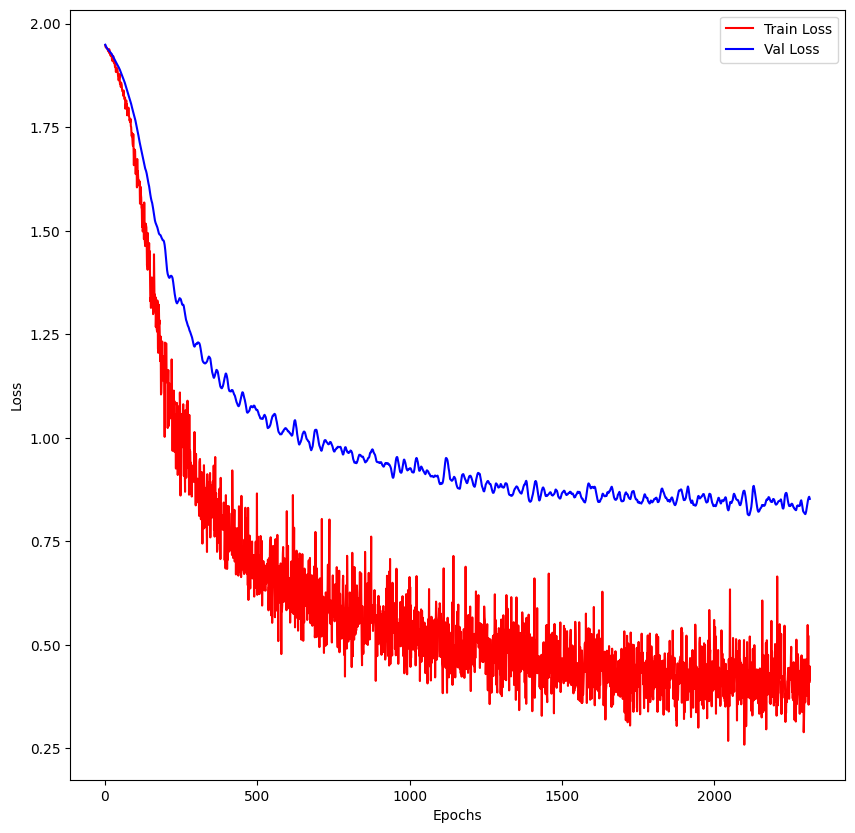

In [22]:
import matplotlib.pyplot as plt

total = len(train_losses)
x_vals = range(1,total+1)
plt.figure(figsize = (10,10))
plt.plot(x_vals,train_losses,color="red",label="Train Loss")
plt.plot(x_vals,val_losses,color="blue",label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_labels():
    model.eval()
    out = model(data)
    pred = torch.argmax(out,dim=1)
    
    y_pred = pred[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    return y_true,y_pred

<Axes: >

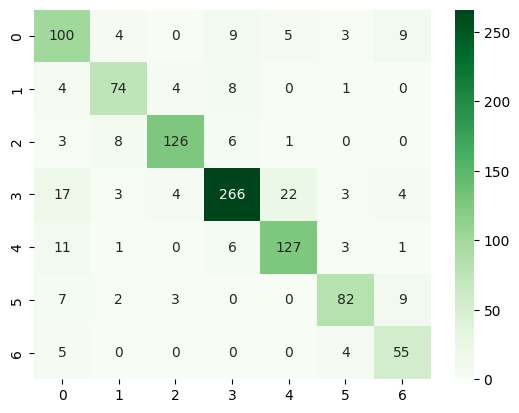

In [24]:
y_true,y_pred = get_labels()
cm = confusion_matrix(y_true=y_true,y_pred=y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap="Greens",xticklabels=range(dataset.num_classes),yticklabels=range(dataset.num_classes))